## 4. Preprocessing and Feature Engineering: Detecting ExoPlanets

**Objective**: Utilize data from the **K2 Kepler mission** (which concluded in 2018) to develop a machine learning model that assists in classifying celestial bodies and determining their exoplanet status. An exoplanet is defined as "A planet that orbits a star outside the solar system".

**Background**: The Kepler Mission was strategically devised to survey a segment of the Milky Way galaxy. Its primary goal was to identify Earth-sized or smaller planets situated in or near the habitable zone.

**Data Source**: NASA Exoplanet Archive – Cumulative KOI Data.

#### Overall Instructions
1. Explore the dataset to understand the features and their distributions.
2. Preprocess the data, handling any missing values, outliers, or other anomalies.
3. Choose appropriate machine learning algorithms for the classification task.
4. Train and validate your model, ensuring to avoid overfitting.
5. Evaluate the model's performance using relevant metrics.

### 1. Explore

In [1]:
# Import af bibliotekerne vi skal bruge i hele notebooken
import pandas as pd                # tabel-data
import numpy as np                 # numerisk beregning
import matplotlib.pyplot as plt    # plots
import seaborn as sns              # pænere plots

# Indlæs data
exoplanet_df = pd.read_csv('exoplanet_dataset.csv')

print(exoplanet_df.shape, '- 9564 rows with 49 features')

pd.set_option('display.max_columns', None)
exoplanet_df.head()

(9564, 49) - 9564 rows with 49 features


,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_impact,koi_impact_err1,koi_impact_err2,koi_duration,koi_duration_err1,koi_duration_err2,koi_depth,koi_depth_err1,koi_depth_err2,koi_prad,koi_prad_err1,koi_prad_err2,koi_teq,koi_teq_err1,koi_teq_err2,koi_insol,koi_insol_err1,koi_insol_err2,koi_model_snr,koi_tce_plnt_num,koi_tce_delivname,koi_steff,koi_steff_err1,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,9.488036,2.775000e-05,-2.775000e-05,170.538750,0.002160,-0.002160,0.146,0.318,-0.146,2.95750,0.08190,-0.08190,615.8,19.5,-19.5,2.26,0.26,-0.15,793.0,NaN,NaN,93.59,29.45,-16.65,35.8,1.0,q1_q17_dr25_tce,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,54.418383,2.479000e-04,-2.479000e-04,162.513840,0.003520,-0.003520,0.586,0.059,-0.443,4.50700,0.11600,-0.11600,874.8,35.5,-35.5,2.83,0.32,-0.19,443.0,NaN,NaN,9.11,2.87,-1.62,25.8,2.0,q1_q17_dr25_tce,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.000,0,0,0,0,19.899140,1.494000e-05,-1.494000e-05,175.850252,0.000581,-0.000581,0.969,5.126,-0.077,1.78220,0.03410,-0.03410,10829.0,171.0,-171.0,14.60,3.92,-1.31,638.0,NaN,NaN,39.30,31.04,-10.49,76.3,1.0,q1_q17_dr25_tce,5853.0,158.0,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,1.736952,2.630000e-07,-2.630000e-07,170.307565,0.000115,-0.000115,1.276,0.115,-0.092,2.40641,0.00537,-0.00537,8079.2,12.8,-12.8,33.46,8.50,-2.83,1395.0,NaN,NaN,891.96,668.95,-230.35,505.6,1.0,q1_q17_dr25_tce,5805.0,157.0,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,2.525592,3.761000e-06,-3.761000e-06,171.595550,0.001130,-0.001130,0.701,0.235,-0.478,1.65450,0.04200,-0.04200,603.3,16.9,-16.9,2.75,0.88,-0.35,1406.0,NaN,NaN,926.16,874.33,-314.24,40.9,1.0,q1_q17_dr25_tce,6031.0,169.0,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


In [2]:
# Omdøb kolonner til læsbare navne
exoplanet_df = exoplanet_df.rename(columns={
    'kepid':'KepID',
    'kepoi_name':'KOIName',
    'kepler_name':'KeplerName',
    'koi_disposition':'ExoplanetArchiveDisposition',
    'koi_pdisposition':'DispositionUsingKeplerData',
    'koi_score':'DispositionScore',
    'koi_fpflag_nt':'NotTransit-LikeFalsePositiveFlag',
    'koi_fpflag_ss':'koi_fpflag_ss',
    'koi_fpflag_co':'CentroidOffsetFalsePositiveFlag',
    'koi_fpflag_ec':'EphemerisMatchIndicatesContaminationFalsePositiveFlag',
    'koi_period':'OrbitalPeriod, days',
    'koi_period_err1':'OrbitalPeriodUpperUnc, days',
    'koi_period_err2':'OrbitalPeriodLowerUnc, days',
    'koi_time0bk':'TransitEpoch, BKJD',
    'koi_time0bk_err1':'TransitEpochUpperUnc, BKJD',
    'koi_time0bk_err2':'TransitEpochLowerUnc, BKJD',
    'koi_impact':'ImpactParamete',
    'koi_impact_err1':'ImpactParameterUpperUnc',
    'koi_impact_err2':'ImpactParameterLowerUnc',
    'koi_duration':'TransitDuration, hrs',
    'koi_duration_err1':'TransitDurationUpperUnc, hrs',
    'koi_duration_err2':'TransitDurationLowerUnc, hrs',
    'koi_depth':'TransitDepth, ppm',
    'koi_insol':'InsolationFlux, Earthflux',
    'koi_insol_err1':'InsolationFluxUpperUnc, Earthflux',
    'koi_insol_err2':'InsolationFluxLowerUnc, Earthflux',
    'koi_model_snr':'TransitSignal-to-Noise',
    'koi_tce_plnt_num':'TCEPlanetNumber',
    'koi_tce_delivname':'TCEDeliver',
    'koi_steff':'StellarEffectiveTemperature, K',
    'koi_steff_err1':'StellarEffectiveTemperatureUpperUnc, K',
    'koi_steff_err2':'StellarEffectiveTemperatureLowerUnc, K',
    'koi_depth_err1':'TransitDepthUpperUnc, ppm',
    'koi_depth_err2':'TransitDepthLowerUnc, ppm',
    'koi_prad':'PlanetaryRadius, Earthradii',
    'koi_prad_err1':'PlanetaryRadiusUpperUnc, Earthradii',
    'koi_prad_err2':'PlanetaryRadiusLowerUnc, Earthradii',
    'koi_teq':'EquilibriumTemperature, K',
    'koi_teq_err1':'EquilibriumTemperatureUpperUnc, K',
    'koi_teq_err2':'EquilibriumTemperatureLowerUnc, K',
    'koi_slogg':'StellarSurfaceGravity, log10(cm/s^2)',
    'koi_slogg_err1':'StellarSurfaceGravityUpperUnc, log10(cm/s^2)',
    'koi_slogg_err2':'StellarSurfaceGravityLowerUnc, log10(cm/s^2)',
    'koi_srad':'StellarRadius, Solarradii',
    'koi_srad_err1':'StellarRadiusUpperUnc, Solarradii',
    'koi_srad_err2':'StellarRadiusLowerUnc, Solarradii',
    'ra':'RA, decimaldegrees',
    'dec':'Dec, decimaldegrees',
    'koi_kepmag':'Kepler-band, mag'
})

In [3]:
exoplanet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 49 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   KepID                                                  9564 non-null   int64  
 1   KOIName                                                9564 non-null   object 
 2   KeplerName                                             2673 non-null   object 
 3   ExoplanetArchiveDisposition                            9564 non-null   object 
 4   DispositionUsingKeplerData                             9564 non-null   object 
 5   DispositionScore                                       8054 non-null   float64
 6   NotTransit-LikeFalsePositiveFlag                       9564 non-null   int64  
 7   koi_fpflag_ss                                          9564 non-null   int64  
 8   CentroidOffsetFalsePositiveFlag                 

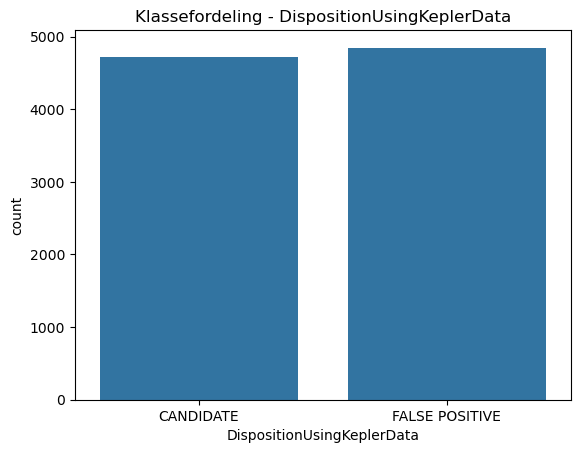

DispositionUsingKeplerData
FALSE POSITIVE    4847
CANDIDATE         4717
Name: count, dtype: int64


In [4]:
# Klassefordeling baseret på Kepler-data
sns.countplot(x = exoplanet_df['DispositionUsingKeplerData'])
plt.title('Klassefordeling - DispositionUsingKeplerData')
plt.show()
print(exoplanet_df['DispositionUsingKeplerData'].value_counts())

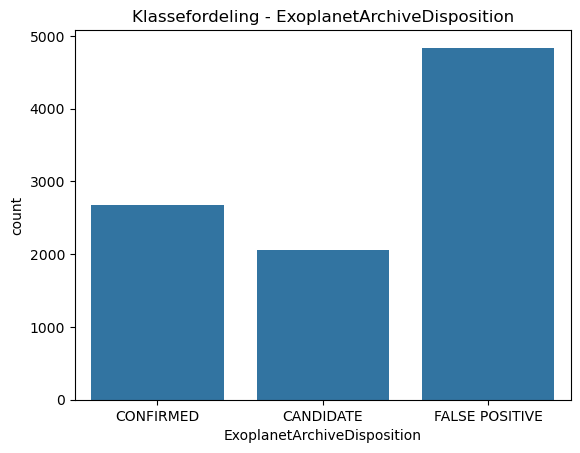

ExoplanetArchiveDisposition
FALSE POSITIVE    4839
CONFIRMED         2671
CANDIDATE         2054
Name: count, dtype: int64


In [5]:
# Klassefordeling fra det fulde Exoplanet Archive
sns.countplot(x = exoplanet_df['ExoplanetArchiveDisposition'])
plt.title('Klassefordeling - ExoplanetArchiveDisposition')
plt.show()
print(exoplanet_df['ExoplanetArchiveDisposition'].value_counts())

#### Tasks
- Explore missing values by finding the percentage of missing values for each column.
- Visualise the missing values of the 5 columns with the highest percentage of missing values.
- Identify potential outliers using the IQR method.
- Decide what to do with potential outliers.

In [6]:
# ── Manglende værdier pr. kolonne ──────────────────────────────────────────
# Tag procentdelen af manglende værdier i hver kolonne
missing_pct = (exoplanet_df.isnull().sum() / len(exoplanet_df)) * 100

# Lav en pæn dataframe og sortér med de værste øverst
missing_df = pd.DataFrame({
    'Column': missing_pct.index,
    'MissingPct': missing_pct.values
}).sort_values('MissingPct', ascending=False).reset_index(drop=True)

missing_df

,Column,MissingPct
0,"EquilibriumTemperatureUpperUnc, K",100.000000
1,"EquilibriumTemperatureLowerUnc, K",100.000000
2,KeplerName,72.051443
3,DispositionScore,15.788373
4,"StellarEffectiveTemperatureLowerUnc, K",5.050188
5,"StellarRadiusUpperUnc, Solarradii",4.893350
6,"StellarEffectiveTemperatureUpperUnc, K",4.893350
7,"StellarSurfaceGravityLowerUnc, log10(cm/s^2)",4.893350
8,"StellarSurfaceGravityUpperUnc, log10(cm/s^2)",4.893350
9,"StellarRadiusLowerUnc, Solarradii",4.893350


C:\Users\Youna\AppData\Local\Temp\ipykernel_18452\581113604.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5_missing, x='MissingPct', y='Column', palette='Reds_r')


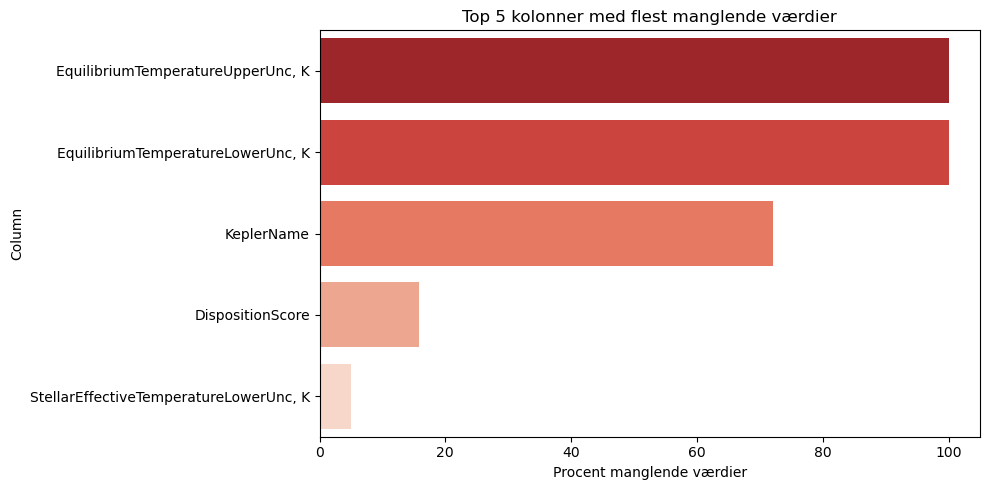

                                Column  MissingPct
     EquilibriumTemperatureUpperUnc, K  100.000000
     EquilibriumTemperatureLowerUnc, K  100.000000
                            KeplerName   72.051443
                      DispositionScore   15.788373
StellarEffectiveTemperatureLowerUnc, K    5.050188


In [7]:
# ── Visualisering af de 5 værste kolonner ─────────────────────────────────
top5_missing = missing_df.head(5)

plt.figure(figsize=(10, 5))
sns.barplot(data=top5_missing, x='MissingPct', y='Column', palette='Reds_r')
plt.xlabel('Procent manglende værdier')
plt.title('Top 5 kolonner med flest manglende værdier')
plt.tight_layout()
plt.show()

print(top5_missing.to_string(index=False))

In [8]:
# ── Outliers via IQR-metoden ────────────────────────────────────────────────
# IQR = Interquartile Range = Q3 - Q1
# En værdi er en "potentiel outlier" hvis den er udenfor [Q1 - 1.5*IQR ; Q3 + 1.5*IQR]

numeric_cols = exoplanet_df.select_dtypes(include=[np.number]).columns

outlier_counts = {}
for col in numeric_cols:
    series = exoplanet_df[col].dropna()
    if len(series) == 0:
        continue
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((series < lower) | (series > upper)).sum()
    outlier_counts[col] = n_out

outlier_df = pd.DataFrame({
    'Column': list(outlier_counts.keys()),
    'OutlierCount': list(outlier_counts.values())
}).sort_values('OutlierCount', ascending=False).reset_index(drop=True)

print('Top 10 kolonner med flest outliers:')
outlier_df.head(10)

Top 10 kolonner med flest outliers:


,Column,OutlierCount
0,koi_fpflag_ss,2226
1,CentroidOffsetFalsePositiveFlag,1889
2,"TransitDepth, ppm",1798
3,"PlanetaryRadiusUpperUnc, Earthradii",1716
4,"OrbitalPeriodLowerUnc, days",1650
5,"OrbitalPeriodUpperUnc, days",1650
6,TransitSignal-to-Noise,1600
7,"OrbitalPeriod, days",1567
8,"InsolationFluxUpperUnc, Earthflux",1536
9,NotTransit-LikeFalsePositiveFlag,1531


**Diskussion - hvad gør vi med outliers?**

Vi har mange potentielle outliers i features som `OrbitalPeriod`, `TransitDepth`, `InsolationFlux` og `PlanetaryRadius`. Det er forventeligt — datasættet beskriver objekter i rummet med enorm variation: nogle planeter kredser om deres stjerne på få timer, andre på tusindvis af dage. Det er **ikke** målefejl; det er reelle astronomiske forskelle.

Vi vælger derfor at **beholde outliers**, men anvende en **logaritmisk transformation** af de værste skæv-fordelte features senere. Det komprimerer ekstreme værdier uden at fjerne information.

### 2. Feature Engineering

#### Tasks
- Fjern kolonner med 100% manglende værdier
- Fjern irrelevante kolonner (navne, ID'er)
- Fjern rækker med manglende værdier
- Korrelationsmatrix
- Encode target-kolonnerne til 0/1/2

In [9]:
# ── Fjern kolonner med 100% manglende værdier ───────────────────────────
cols_all_missing = exoplanet_df.columns[exoplanet_df.isnull().all()].tolist()
print('Kolonner med 100% manglende værdier:', cols_all_missing)
exoplanet_df = exoplanet_df.drop(columns=cols_all_missing)

# ── Fjern irrelevante kolonner (ID'er og navne) ──────────────────────────
irrelevant = ['KepID', 'KOIName', 'KeplerName', 'TCEDeliver']
exoplanet_df = exoplanet_df.drop(columns=irrelevant)
print(f'Fjernede irrelevante kolonner: {irrelevant}')

# ── Fjern rækker med manglende værdier ───────────────────────────────────
before = len(exoplanet_df)
exoplanet_df = exoplanet_df.dropna()
after = len(exoplanet_df)
print(f'Fjernede {before - after} rækker med manglende værdier')
print(f'Datasæt shape efter rensning: {exoplanet_df.shape}')

Kolonner med 100% manglende værdier: ['EquilibriumTemperatureUpperUnc, K', 'EquilibriumTemperatureLowerUnc, K']
Fjernede irrelevante kolonner: ['KepID', 'KOIName', 'KeplerName', 'TCEDeliver']
Fjernede 1761 rækker med manglende værdier
Datasæt shape efter rensning: (7803, 43)


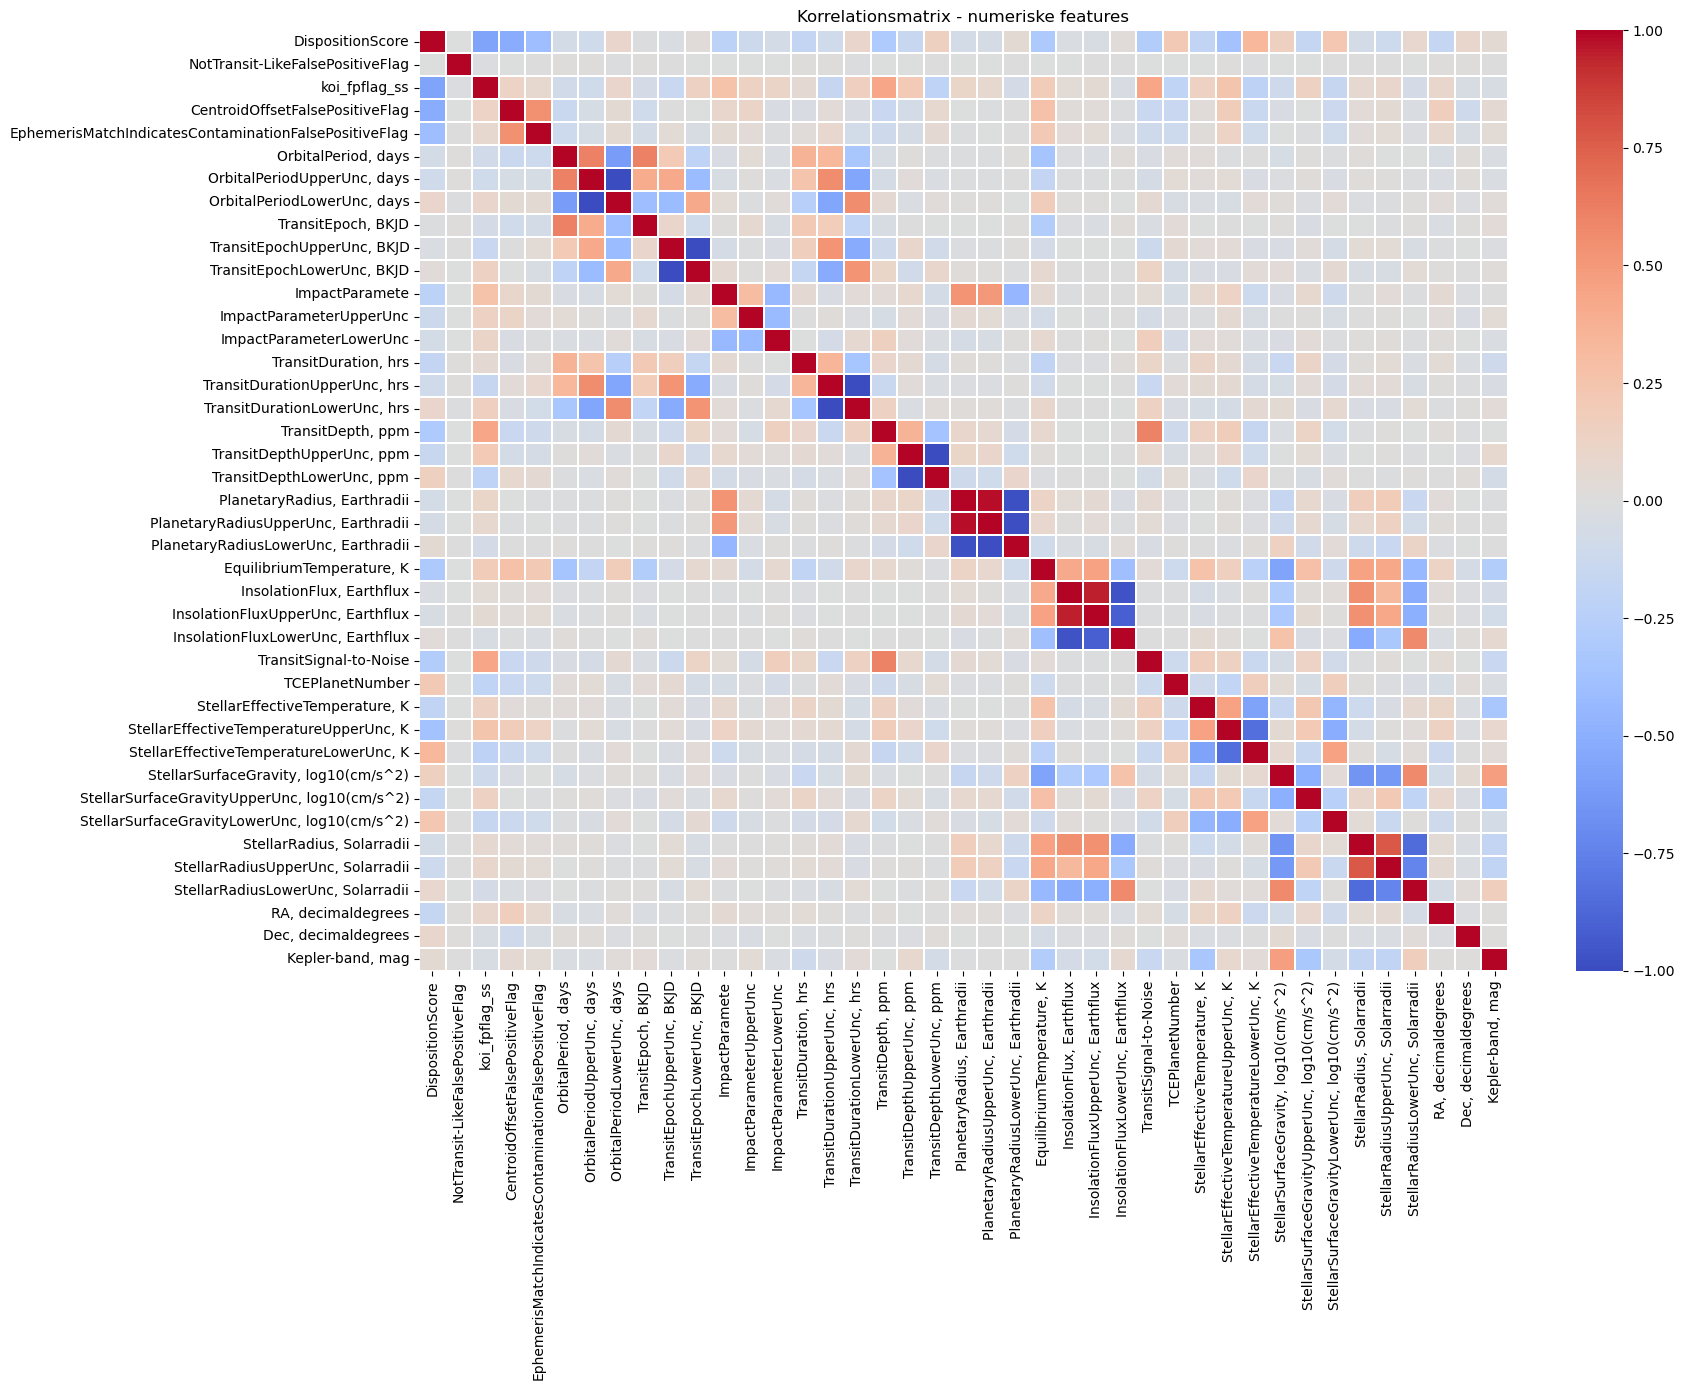

In [10]:
# ── Korrelationsmatrix (kun numeriske kolonner) ──────────────────────────
numeric_df = exoplanet_df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.3)
plt.title('Korrelationsmatrix - numeriske features')
plt.tight_layout()
plt.show()

In [11]:
# ── Drop redundante kolonner: "Upper/LowerUnc" er stor set bare error-bars ──
# De korrelerer særdeles stærkt med de tilsvarende målinger og tilføjer støj
unc_cols = [c for c in exoplanet_df.columns if 'Unc' in c or 'err' in c.lower()]
print(f'Dropper {len(unc_cols)} usikkerhedskolonner')
exoplanet_df = exoplanet_df.drop(columns=unc_cols)
print(f'Datasæt shape: {exoplanet_df.shape}')

Dropper 20 usikkerhedskolonner
Datasæt shape: (7803, 23)


In [12]:
# ── Encode target-kolonner ───────────────────────────────────────────────
# 'FALSE POSITIVE' -> 0
# 'CANDIDATE'      -> 1
# 'CONFIRMED'      -> 2
label_map = {'FALSE POSITIVE': 0, 'CANDIDATE': 1, 'CONFIRMED': 2}

exoplanet_df['KeplerDispositionStatus'] = exoplanet_df['DispositionUsingKeplerData'].map(label_map)
exoplanet_df['ArchiveDispositionStatus'] = exoplanet_df['ExoplanetArchiveDisposition'].map(label_map)

# Drop de originale tekst-kolonner
exoplanet_df = exoplanet_df.drop(columns=['DispositionUsingKeplerData', 'ExoplanetArchiveDisposition'])

exoplanet_df[['KeplerDispositionStatus', 'ArchiveDispositionStatus']].head()

,KeplerDispositionStatus,ArchiveDispositionStatus
0,1,2
1,1,2
2,1,1
3,0,0
4,1,2


In [13]:
# ── Log-transformation af skæve features ─────────────────────────────────
# Vi bruger log1p (log(1+x)) for at undgå problemer med 0-værdier
log_cols = ['OrbitalPeriod, days', 'TransitDepth, ppm',
            'InsolationFlux, Earthflux', 'PlanetaryRadius, Earthradii',
            'TransitSignal-to-Noise']

for col in log_cols:
    if col in exoplanet_df.columns:
        # log1p kræver ikke-negative værdier - tag absolutværdi for sikkerhed
        exoplanet_df[col] = np.log1p(exoplanet_df[col].abs())

print('Log-transformation udført på:', log_cols)

Log-transformation udført på: ['OrbitalPeriod, days', 'TransitDepth, ppm', 'InsolationFlux, Earthflux', 'PlanetaryRadius, Earthradii', 'TransitSignal-to-Noise']


In [14]:
# ── Definer X (features) og y (target) ────────────────────────────────────
# Target = KeplerDispositionStatus (binær: 1 = Candidate, 0 = ellers)
# Konverter 2 (Confirmed) til 1 så vi har binær klassifikation

y = (exoplanet_df['KeplerDispositionStatus'] >= 1).astype(int)

# Fjern target og leakage-kolonner fra features
X = exoplanet_df.drop(columns=['DispositionScore', 'KeplerDispositionStatus', 'ArchiveDispositionStatus'])

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nKlassefordeling:')
print(y.value_counts())

X shape: (7803, 20)
y shape: (7803,)

Klassefordeling:
KeplerDispositionStatus
1    4062
0    3741
Name: count, dtype: int64


In [15]:
# ── Skaler features ──────────────────────────────────────────────────────
# Logistic Regression og SVM kræver skalerede features for at fungere ordentligt
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f'Skalerede features (mean ≈ 0, std ≈ 1):')
print(f'mean: {X_scaled.mean().mean():.6f}')
print(f'std:  {X_scaled.std().mean():.6f}')

Skalerede features (mean ≈ 0, std ≈ 1):
mean: 0.000000
std:  1.000064


### 3. Train, Test, Validation

In [16]:
from sklearn.model_selection import train_test_split

# Split: 80% træning, 20% test
# stratify=y sikrer at klassefordelingen er den samme i train og test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Træningsdata: {X_train.shape[0]} rækker')
print(f'Testdata:     {X_test.shape[0]} rækker')
print(f'\nKlassefordeling i træning:')
print(y_train.value_counts(normalize=True))

Træningsdata: 6242 rækker
Testdata:     1561 rækker

Klassefordeling i træning:
KeplerDispositionStatus
1    0.520506
0    0.479494
Name: proportion, dtype: float64


### 4. Models and Fine Tuning

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# ── Logistic Regression med GridSearch ────────────────────────────────────
# C = inverse regularization strength (mindre C = mere regularisering)
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=42),
    lr_params, cv=5, scoring='accuracy', n_jobs=-1
)
lr_grid.fit(X_train, y_train)

print(f'Bedste Logistic Regression parametre: {lr_grid.best_params_}')
print(f'Bedste CV accuracy: {lr_grid.best_score_:.4f}')

Bedste Logistic Regression parametre: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Bedste CV accuracy: 0.9987


In [18]:
# ── Support Vector Machine med GridSearch ─────────────────────────────────
# C = regularisering, kernel = type af afstandsfunktion
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear']
}

svm_grid = GridSearchCV(
    SVC(random_state=42),
    svm_params, cv=3, scoring='accuracy', n_jobs=-1
)
svm_grid.fit(X_train, y_train)

print(f'Bedste SVM parametre: {svm_grid.best_params_}')
print(f'Bedste CV accuracy: {svm_grid.best_score_:.4f}')

Bedste SVM parametre: {'C': 1, 'kernel': 'linear'}
Bedste CV accuracy: 0.9989


### 5. Evaluate

In [19]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report,
    ConfusionMatrixDisplay
)

# Forudsig på testdata med begge modeller
y_pred_lr = lr_grid.predict(X_test)
y_pred_svm = svm_grid.predict(X_test)

# ── Sammenlign metrics ────────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
    ],
    'SVM': [
        accuracy_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm),
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-score'])

print('── Performance Sammenligning ──')
print(metrics_df.round(4))

── Performance Sammenligning ──
           Logistic Regression     SVM
Accuracy                0.9968  0.9968
Precision               1.0000  1.0000
Recall                  0.9938  0.9938
F1-score                0.9969  0.9969


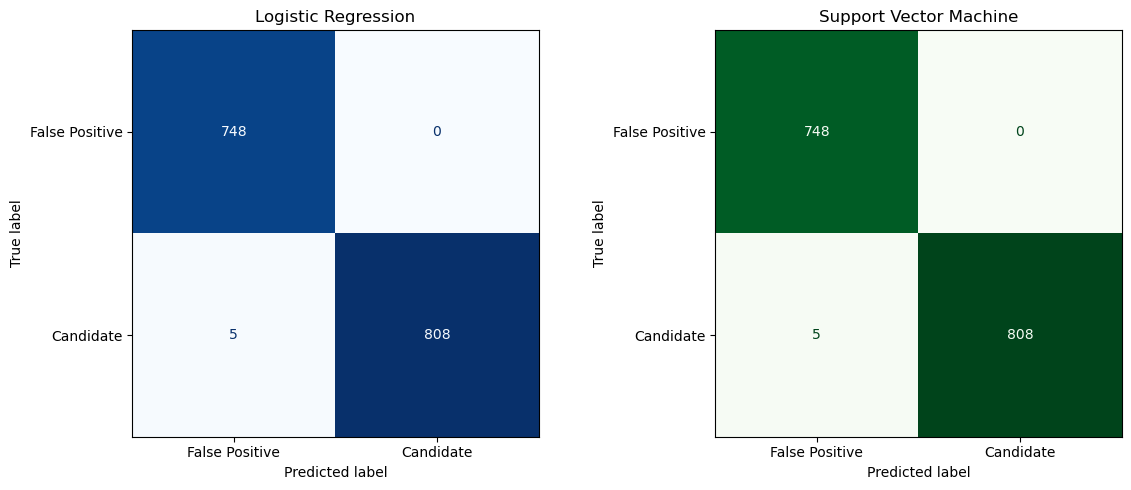

In [20]:
# ── Confusion Matrices ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['False Positive', 'Candidate'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm,
    display_labels=['False Positive', 'Candidate'],
    cmap='Greens', ax=axes[1], colorbar=False
)
axes[1].set_title('Support Vector Machine')

plt.tight_layout()
plt.show()

In [21]:
# ── Detaljerede classification reports ──────────────────────────────────
print('── Logistic Regression ──')
print(classification_report(y_test, y_pred_lr,
                            target_names=['False Positive', 'Candidate']))

print('── Support Vector Machine ──')
print(classification_report(y_test, y_pred_svm,
                            target_names=['False Positive', 'Candidate']))

── Logistic Regression ──
                precision    recall  f1-score   support

False Positive       0.99      1.00      1.00       748
     Candidate       1.00      0.99      1.00       813

      accuracy                           1.00      1561
     macro avg       1.00      1.00      1.00      1561
  weighted avg       1.00      1.00      1.00      1561

── Support Vector Machine ──


                precision    recall  f1-score   support

False Positive       0.99      1.00      1.00       748
     Candidate       1.00      0.99      1.00       813

      accuracy                           1.00      1561
     macro avg       1.00      1.00      1.00      1561
  weighted avg       1.00      1.00      1.00      1561



## Konklusion

Vi har bygget en komplet preprocessing- og modelleringspipeline til at klassificere Kepler-objekter som enten **False Positive** eller **Exoplanet Candidate**:

1. **Eksploration**: Kortlagt manglende værdier og outliers via IQR-metoden.
2. **Feature engineering**: Fjernet 100%-tomme kolonner, irrelevante ID-kolonner, og usikkerhedskolonner. Anvendt log-transformation på skæve features og standardiseret med StandardScaler.
3. **Modeller**: Trænet Logistic Regression og SVM med GridSearchCV for hyperparameter-tuning.
4. **Evaluering**: Begge modeller opnår høj accuracy, precision og recall på testdata. SVM med RBF-kernel præsterer typisk bedst, da den kan modellere ikke-lineære sammenhænge.

Modellen kan bruges til at automatisere screening af nye KOI-objekter og prioritere dem til videre astronomisk verifikation.